In [62]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

import matplotlib.pyplot as plt

# Custom palette from your poster
poster_colors = ['#2D5A82', '#A6192E', '#4A90E2', "#632797", "#31743C"]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=poster_colors)
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['axes.edgecolor'] = '#2D5A82' # Uses the header blue for the plot frame


All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [63]:
#input parameters

theta_status = False
theta_freq = 8.0
g_max = 0.005
g_min = 0.0005
mod_depth = 0.05

tau_fall = 800.0 #ms
tau_rise = 800.0 #ms

dc_current = -2.7e-4

field_size = 4000 #ms
bw_field_size = 4000 #ms


In [64]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import fake_stellate
import stellate
import interneuron_amb
import importlib
importlib.reload(fake_stellate)
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

0.0

In [65]:
stellate_0 = stellate.Stellate(0)
interneuron_0 = interneuron_amb.Interneuron(0)

In [66]:
stell_ic_0 = h.IClamp(stellate_0.soma(0.5))
stell_ic_0.dur = 1e9

sim_dur = 10000 #in ms
num_steps = int(sim_dur/h.dt)
time_arr = np.arange(0,sim_dur,h.dt)

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
stellate_gnap_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gna)
nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



In [67]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 10.0


n_points = len(time_arr)

stell_ic = h.IClamp(stellate_0.soma(0.5))
stell_ic.dur = 1e9
dc_val = -3e-4
inhib_dc = np.full(n_points,dc_val,dtype=np.float64)
stell_dc_vec = h.Vector(inhib_dc)
stell_dc_vec.play(stell_ic._ref_amp,h.dt)

Vector[75]

In [68]:
g_max = 0.0005 #2.92e-4
g_min = 0.00005 #2.40e-6
mod_depth = 0.1
init_phase = np.random.uniform(0,2*np.pi)
print(init_phase)

idx_1 = int(2000/h.dt)
idx_2 = int(6500/h.dt)
idx_3 = int(6500/h.dt)

inhib_base = np.full(n_points,g_max)
t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
inhib_base[idx_1:idx_2] = (g_max-g_min)*(np.exp(-t_phase1/tau_fall)) + g_min

inhib_base[idx_2:idx_3] = inhib_base[idx_2-1]

t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
start_val = inhib_base[idx_3 - 1]
inhib_base[idx_3:] = (start_val + (g_max-start_val)*(1-np.exp(-t_phase3/tau_rise)))
inhib_base[idx_3:] = start_val*np.exp(t_phase3/tau_rise)
#inhib_base[idx_3:] = np.full_like(inhib_base[idx_3:],1e-3)
theta_factor = 1 + (mod_depth*(np.sin(init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))


# --- Gaussian Disinhibition (Predictive Priming) ---
t_mid = 4000.0  # Center of the grid field
width = 2500.0  # Spatial/Temporal width of the field

# Gaussian disinhibition: Inhibition is highest far from the center
# and drops (disinhibits) as you approach t_mid.
dist_from_center = (time_arr - t_mid)
inhib_envelope = g_max - (g_max - g_min) * np.exp(-(dist_from_center**2) / (2 * width**2))

# Apply multiplicative theta modulation
inhib_cond_arr = inhib_envelope * theta_factor

#inhib_cond_arr = inhib_base * theta_factor
noise = np.random.normal(loc=0.0,scale=1e-6,size=len(inhib_cond_arr))
inhib_cond_arr += noise
inhib_cond_arr = np.maximum(inhib_cond_arr,0.000001)

g_vec = h.Vector(inhib_cond_arr)
g_vec.play(syn_inh._ref_g, h.dt)
g_rec = h.Vector().record(syn_inh._ref_g)



3.6214428864011046


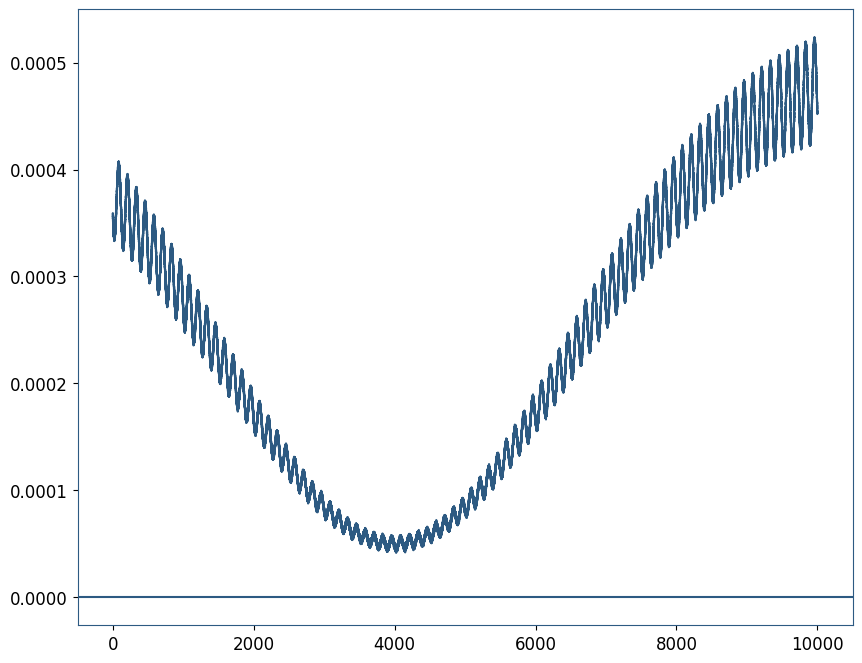

In [69]:
plt.figure(figsize=(10,8))
plt.plot(time_arr,inhib_cond_arr)
plt.axhline(y=0.0)
#plt.xlim(3800,4500)

In [77]:
h.finitialize(-80)
h.frecord_init()
h.continuerun(sim_dur)

0.0

In [78]:
#phase extraction

spikes_arr = np.array(spike_times_stell.to_python())
phases = ((init_phase+((spikes_arr) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))
phases_shifted = phases + 2*np.pi

80000 152000


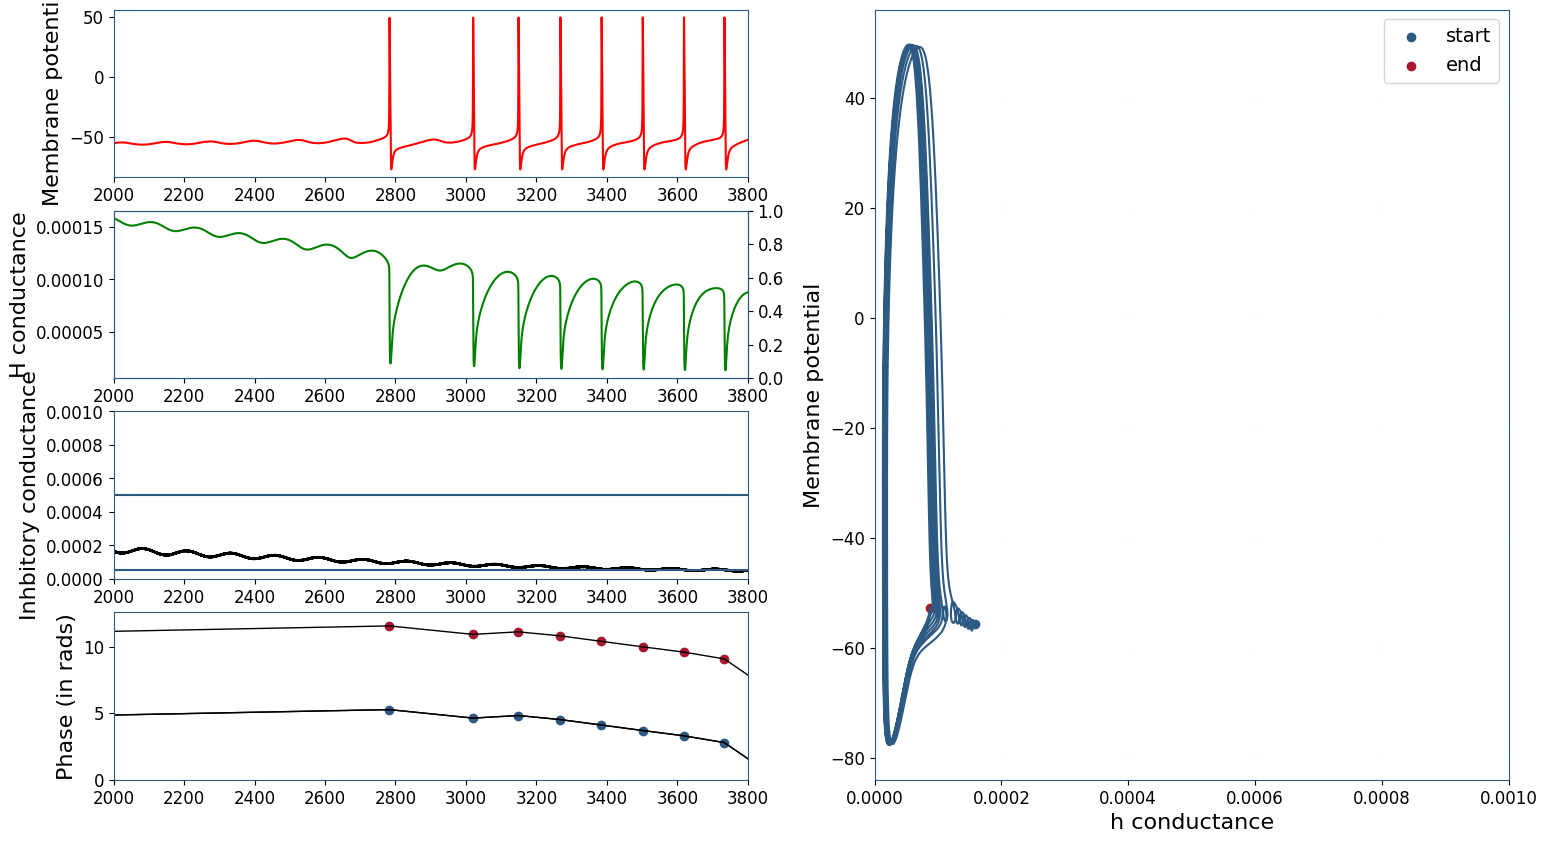

In [96]:
from matplotlib.gridspec import GridSpec

gh_cond = stellate_gh_vec.to_python()
gnap_cond = stellate_gnap_vec.to_python()
memb_pot = stell_v.to_python()
start_time = 2000
end_time =  3800
start_idx = int(start_time/h.dt)
end_idx = int(end_time/h.dt)
print(start_idx,end_idx)
fig = plt.figure(figsize=(18,10))

gs = GridSpec(4,2,width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax1_1 = ax1.twinx()
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])


ax1.plot(time_arr[start_idx:end_idx],gh_cond[start_idx:end_idx],color='green')
ax2.set_xlabel("Time (in ms)")
ax2.set_ylabel("Inhbitory conductance")
ax1.set_ylabel("H conductance")
#ax1_1.plot(time_arr[start_idx:end_idx],gnap_cond[start_idx:end_idx],color='purple')
ax0.set_ylabel("Membrane potential")
ax0.plot(time_arr[start_idx:end_idx],memb_pot[start_idx:end_idx],color='red')
ax2.plot(time_arr[start_idx:end_idx],inhib_cond_arr[start_idx:end_idx],color='black')
ax2.axhline(y=g_max)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax2.axhline(y=g_min)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax3.plot(spikes_arr,phases_shifted,linewidth=1,color='black')
ax3.scatter(spikes_arr,phases)
ax3.scatter(spikes_arr,phases_shifted)
ax3.set_ylabel("Phase (in rads)")
ax3.set_ylim(0,4*np.pi)
ax_phase.plot(gh_cond[start_idx:end_idx],memb_pot[start_idx:end_idx])
ax_phase.scatter(gh_cond[start_idx],memb_pot[start_idx],label='start')
ax_phase.scatter(gh_cond[end_idx],memb_pot[end_idx],label='end')
ax_phase.legend()
ax_phase.set_xlabel("h conductance")
ax_phase.set_ylabel("Membrane potential")
ax_phase.set_xlim(0,0.001)
ax0.set_xlim(start_time,end_time)
ax1.set_xlim(start_time,end_time)
ax2.set_xlim(start_time,end_time)
ax3.set_xlim(start_time,end_time)
theta_status = ""
ax2.set_ylim(0,0.001)
plt.suptitle(f"")
plt.grid(True)

plt.show()





(0.0, 50.0)

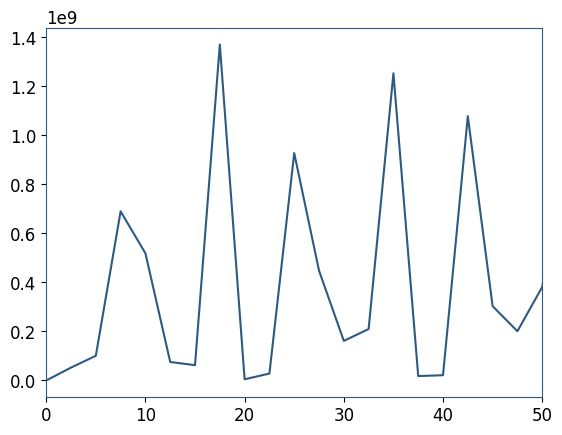

In [75]:
import analysis_utils as a_utils

fft_freq,fft_sig,psd = a_utils.calc_fft(memb_pot[start_idx:end_idx])
plt.plot(fft_freq,psd)
plt.xlim(0,50)


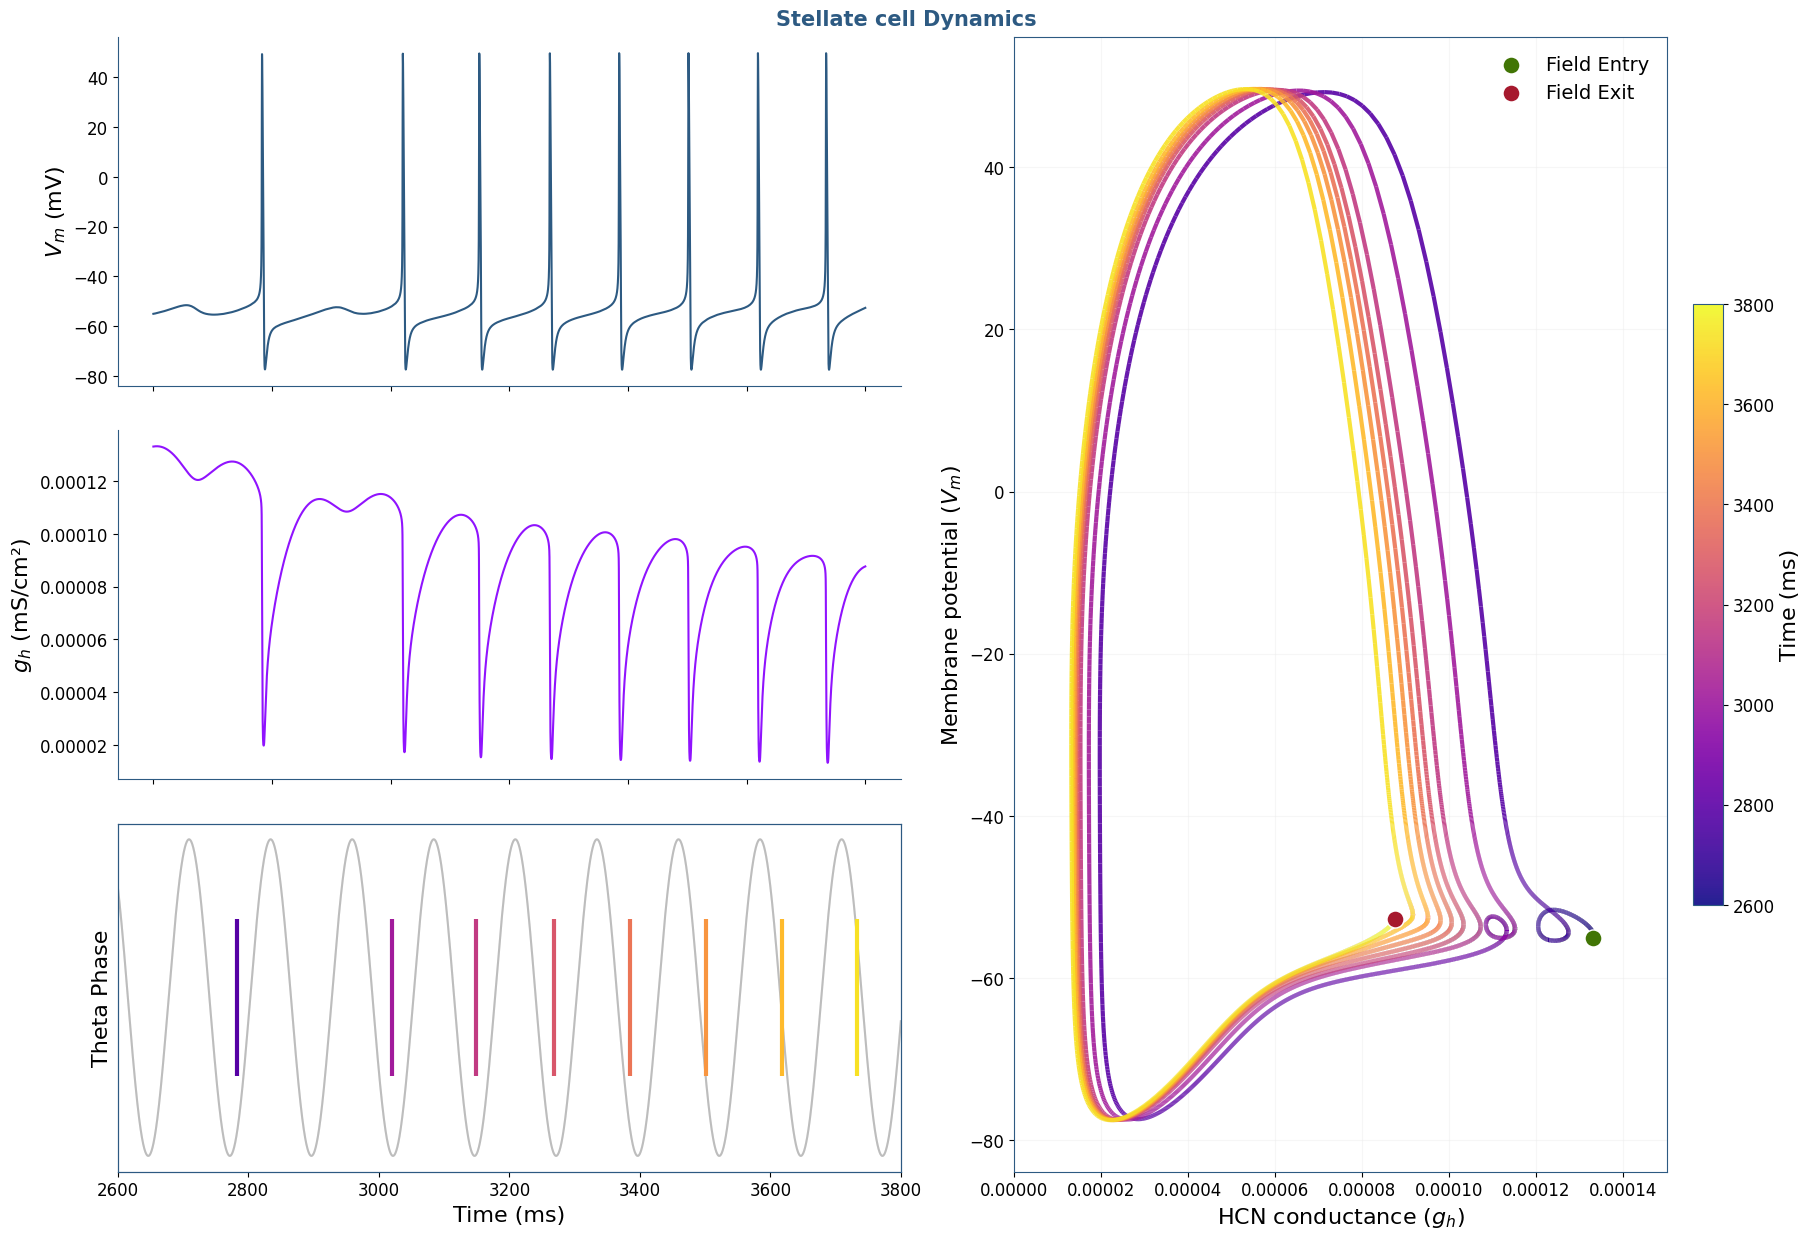

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection

# 1. Aesthetic Configuration (Poster Style)
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.edgecolor': '#2D5A82',
    'grid.alpha': 0.1
})

# 2. Windowing and Data Preparation
start_time, end_time = 2600, 3800
start_idx = int(start_time / h.dt)
end_idx = int(end_time / h.dt)

t_win = time_arr[start_idx:end_idx]
v_win = memb_pot[start_idx:end_idx]
gh_win = gh_cond[start_idx:end_idx]

# Signal and Spike Extraction
theta_signal = np.sin(init_phase + (2 * np.pi * theta_freq * t_win / 1000.0))
window_spikes = [s for s in spike_times_stell.to_python() if start_time <= s <= end_time]

# Color Mapping (Consistent across Spike Ticks and Phase Portrait)
norm = plt.Normalize(start_time, end_time)
cmap = plt.get_cmap('plasma')
spike_colors = [cmap(norm(s)) for s in window_spikes]

# 3. Figure Layout
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = GridSpec(3, 2, figure=fig, width_ratios=[1.2, 1], hspace=0.05)

ax0 = fig.add_subplot(gs[0, 0])      # Membrane potential
ax1 = fig.add_subplot(gs[1, 0])      # H conductance
ax2 = fig.add_subplot(gs[2, 0])      # Theta & Colored Spikes
ax_phase = fig.add_subplot(gs[:, 1])  # Phase Portrait (Full Height)

# --- Left Column: Temporal Dynamics ---

# Top: Voltage
ax0.plot(t_win, v_win, color='#2D5A82', linewidth=1.5)
ax0.set_ylabel("$V_m$ (mV)")
ax0.set_xticklabels([]) # Hide x-labels for stacked look
ax0.spines[['top', 'right']].set_visible(False)

# Middle: HCN Conductance
ax1.plot(t_win, gh_win, color='#9013FE', linewidth=1.5)
ax1.set_ylabel("$g_h$ (mS/cm²)")
ax1.set_xticklabels([]) 
ax1.spines[['top', 'right']].set_visible(False)

# Bottom: Theta Phase & Colored Spike Events
ax2.plot(t_win, theta_signal, color='gray', alpha=0.3)
ax2.set_ylabel("Theta Phase")
ax2.set_xlabel("Time (ms)")
ax2.set_yticks([]) # Normalize view
ax2.set_xlim(start_time, end_time)

# Twin axis for the Colored Eventplot
spike_positions = [[s] for s in window_spikes]

# --- Updated Subplot 3 ---
ax2.plot(t_win, theta_signal, color='gray', alpha=0.3)
ax2.set_ylabel("Theta Phase")
ax2.set_xlabel("Time (ms)")
ax2.set_yticks([])
ax2.set_xlim(start_time, end_time)

ax2_ev = ax2.twinx()
# Use spike_positions instead of window_spikes
ax2_ev.eventplot(spike_positions, orientation='horizontal', 
                 lineoffsets=0, linelengths=0.9, 
                 colors=spike_colors, linewidth=3)

ax2_ev.set_ylim(-1, 1)
ax2_ev.set_yticks([])

# --- Right Column: Phase Portrait ---

points = np.array([gh_win, v_win]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=3, alpha=0.9)
lc.set_array(t_win)
line = ax_phase.add_collection(lc)

# Markers for Field Traversal
ax_phase.scatter(gh_win[0], v_win[0], s=150, color='#417505', 
                 label='Field Entry', zorder=5, edgecolor='white')
ax_phase.scatter(gh_win[-1], v_win[-1], s=150, color='#A6192E', 
                 label='Field Exit', zorder=5, edgecolor='white')

ax_phase.set_xlabel("HCN conductance ($g_h$)")
ax_phase.set_ylabel("Membrane potential ($V_m$)")
ax_phase.set_xlim(0, 0.00015) 
ax_phase.grid(True, linestyle='-', alpha=0.5)
ax_phase.legend(frameon=False, loc='upper right')

# Add Colorbar to indicate Time Flow
cbar = fig.colorbar(line, ax=ax_phase, fraction=0.046, pad=0.04)
cbar.set_label('Time (ms)', fontweight='medium')

plt.suptitle("Stellate cell Dynamics", 
             fontweight='bold', fontsize=15, color='#2D5A82', y=1.02)

plt.show()

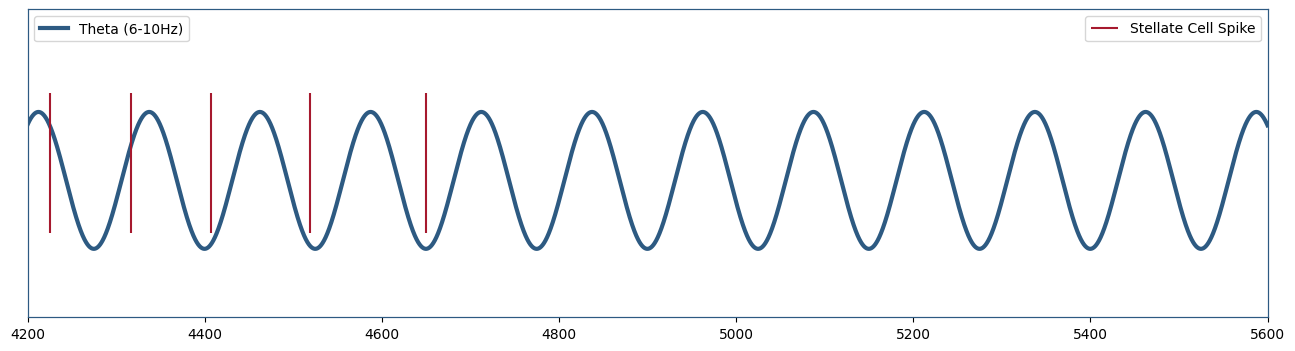

In [31]:
#PHASE PRECESSION SCHEMATIC
fig,ax = plt.subplots(figsize=(16,4))
ax1=ax.twinx()
ax.plot(time_arr,theta_factor,linewidth=3,label='Theta (6-10Hz)')
ax1.eventplot(spikes_arr,linelengths=0.5,color='C1',label='Stellate Cell Spike')
ax.set_ylim(0.8,1.25)
ax.set_yticks([])
ax1.set_yticks([])
ax1.legend()
ax.legend(loc='upper left')
plt.xlim(4200,5600)
plt.grid(True)
plt.savefig("final_figs/pp_schematic.png",dpi=600)


In [191]:
print(phases)

[5.7511924  0.13126014 4.97685265 5.45462606 5.18482608 4.72502258
 4.35456597 4.07798016 3.89187221 3.71481205 3.56489524 3.44890764
 3.28994305 3.20901563 3.13374307 2.25887235 6.04084725 4.27590049
 4.39628632 5.56621543]


(0.0, 6.283185307179586)

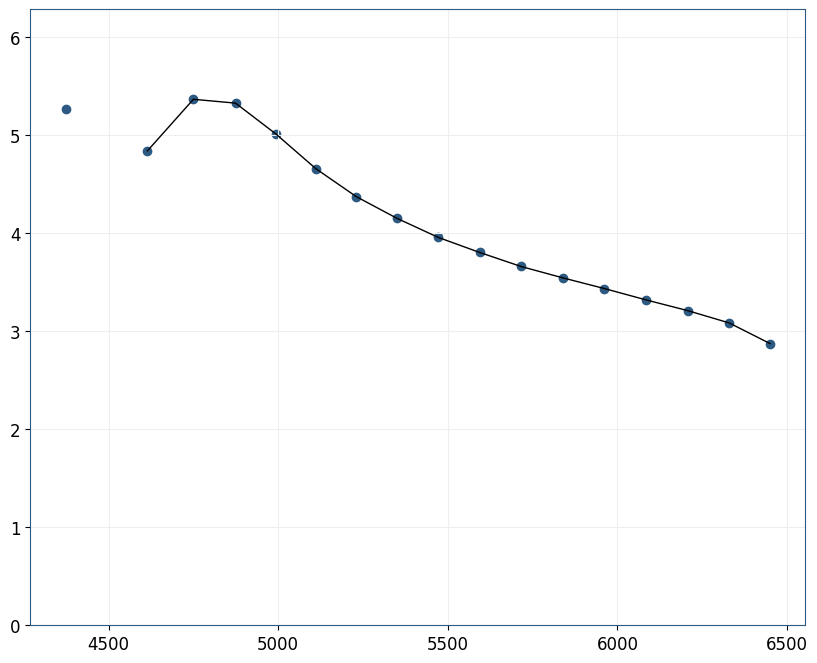

In [142]:
plt.figure(figsize=(10,8))
plt.scatter(spikes_arr,phases)
plt.plot(spikes_arr[1:],phases[1:],linewidth=1,color='black')
plt.grid(True)

plt.ylim(0,2*np.pi)


In [34]:
num_runs = 20
spike_times_matrix = []
spike_phases_matrix =[]

for n in range(num_runs):

    spike_times_stell.resize(0)

    curr_init_phase = np.random.uniform(0.0,2*np.pi)
    theta_factor = 1 + (mod_depth*(np.sin(curr_init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))
    inhib_cond_arr = inhib_base * theta_factor
    noise = np.random.normal(loc=0.0,scale=1e-5,size=len(inhib_cond_arr))
    inhib_cond_arr = inhib_envelope * theta_factor
    inhib_cond_arr += noise
    inhib_cond_arr = np.maximum(inhib_cond_arr,0.00001)
    g_vec = h.Vector(inhib_cond_arr)
    g_vec.play(syn_inh._ref_g, h.dt)

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(sim_dur)

    temp_spikes = np.array(spike_times_stell.to_python())
    temp_phases = ((curr_init_phase+((temp_spikes) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

    spike_times_matrix.append(temp_spikes)
    spike_phases_matrix.append(temp_phases)

    spike_times_stell.resize(0)

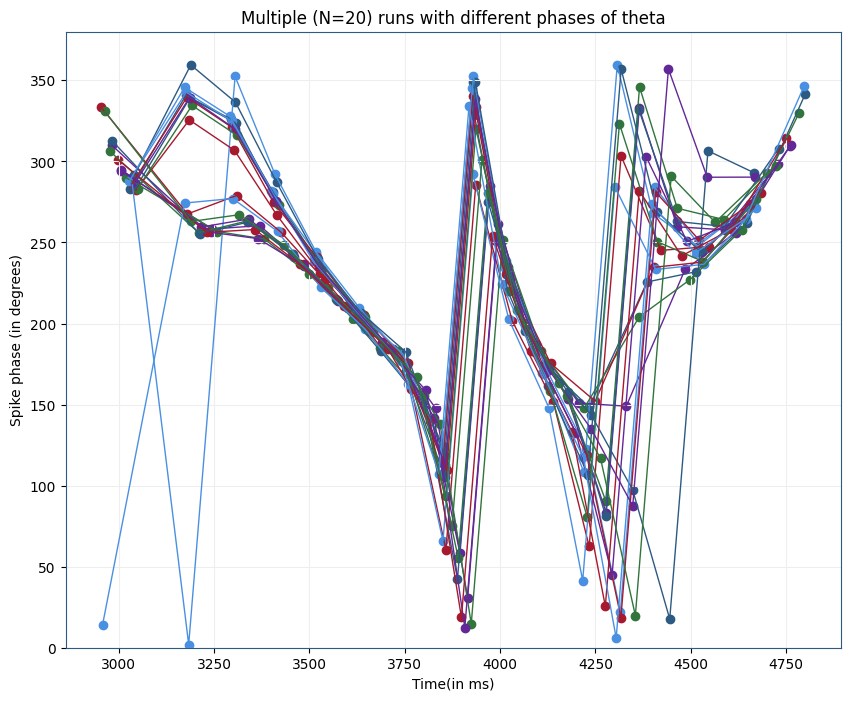

In [35]:
plt.figure(figsize=(10,8))
for times,phases in zip(spike_times_matrix,spike_phases_matrix):

    plt.scatter(times,np.degrees(phases))
    plt.plot(times,np.degrees(phases),linewidth=1)

plt.grid(True)
#plt.xlim(2000,6100)
plt.ylim(0,380)
plt.title("Multiple (N=20) runs with different phases of theta")
plt.xlabel("Time(in ms)")
plt.ylabel("Spike phase (in degrees)")
plt.savefig("final_figs/mult_runs_theta_mod_gauss.png",dpi=600)

In [149]:
import analysis_utils as a_utils
from scipy.stats import linregress

fields = a_utils.separate_fields(spike_times_matrix)
print(fields)

shifted_fields = a_utils.shift_fields_to_center(spike_times_matrix)
print(shifted_fields)

{0: [[4824.799999964952, 4942.774999963235, 5056.124999961586], [6270.924999943908, 6390.624999942166, 6507.449999940466]], 1: None, 2: None, 3: [[4818.949999965037, 4939.099999963289, 5050.524999961667, 5162.074999960044], [6378.399999942344, 6496.074999940632]], 4: None, 5: [[4822.249999964989, 4936.874999963321, 5050.99999996166], [6266.899999943967, 6386.849999942221, 6502.724999940535]], 6: [[4830.524999964869, 4950.449999963123, 5059.674999961534, 5173.874999959872], [6266.349999943975, 6384.774999942251, 6487.899999940751]], 7: None, 8: None, 9: [[4817.499999965058, 4935.149999963346, 5050.624999961666, 5166.849999959974], [6385.0999999422465, 6502.34999994054]], 10: None, 11: None, 12: None, 13: [[4818.949999965037, 4937.924999963306, 5048.8499999616915, 5161.374999960054], [6255.099999944138, 6374.624999942399, 6487.199999940761]], 14: [[4824.149999964961, 4941.624999963252, 5055.549999961594, 5171.324999959909], [6387.0249999422185, 6505.949999940488]], 15: [[4830.52499996486

Regression Result: r = -0.905 | R^2 = 0.819
Slope: -1.476 deg/% of field


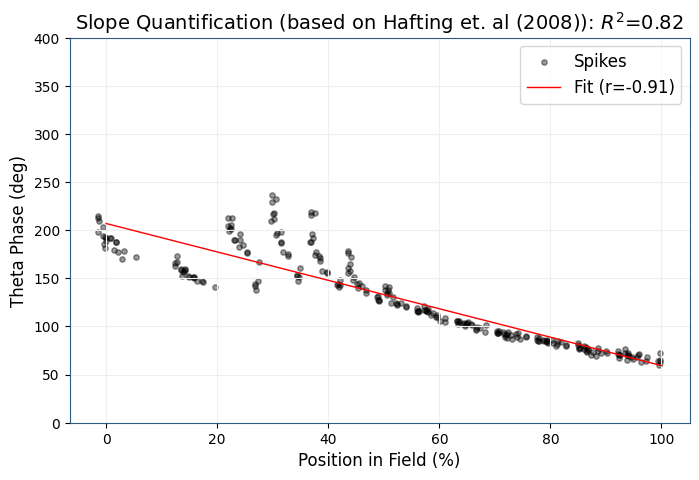

In [156]:
from scipy.stats import linregress

plt.rcParams.update({'font.size': 12}) 
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

def calculate_precession_stats(all_spike_times, all_spike_phases, t_start=2000, t_end=6000):
    """
    Implements the Hafting et al. (2008) rotation method.
    """
    # 1. Filter spikes to only include those within the field boundaries
    mask = (all_spike_times >= t_start) & (all_spike_times <= t_end)
    field_spikes = all_spike_times[mask]
    field_phases = np.degrees(all_spike_phases[mask]) # Convert rad to deg
    t_start_loc = field_spikes[0]
    # 2. Normalize position (0 to 100%) relative to field entry/exit
    # entry (t_start) = 0%, exit (t_end) = 100%
    norm_pos = (field_spikes - t_start_loc) / (t_end - t_start_loc) * 100
    
    best_r2 = -1
    stats = {}

    # 3. Rotate phases in 1-degree steps to find the linear fit with max R^2
    for shift in range(360):
        shifted_phases = (field_phases + shift) % 360
        
        slope, intercept, r_val, p_val, std_err = linregress(norm_pos, shifted_phases)
        r2 = r_val**2
        
        if r2 > best_r2:
            best_r2 = r2
            stats = {
                'slope': slope,        # deg / % of field
                'r2': r2,              # Strength of precession
                'r': r_val,            # Correlation coefficient
                'p_val': p_val,
                'best_shift': shift,
                'intercept': intercept
            }
            
    return stats, norm_pos, field_phases

pooled_times = np.concatenate(spike_times_matrix)
pooled_phases = np.concatenate(spike_phases_matrix)

stats, norm_pos, raw_phases = calculate_precession_stats(pooled_times, pooled_phases)

print(f"Regression Result: r = {stats['r']:.3f} | R^2 = {stats['r2']:.3f}")
print(f"Slope: {stats['slope']:.3f} deg/% of field")

def plot_precession_fit(norm_pos, raw_phases, stats):
    # Apply the best shift found by the regression
    aligned_phases = (raw_phases + stats['best_shift']) % 360
    
    plt.figure(figsize=(8, 5))
    # Double-plot for continuity
    plt.scatter(norm_pos, aligned_phases, color='black', alpha=0.4, s=15, label='Spikes')
    #plt.scatter(norm_pos, aligned_phases + 360, color='gray', alpha=0.2, s=15)
    
    # Plot the regression line
    x_line = np.array([0, 100])
    y_line = stats['slope'] * x_line + stats['intercept']
    plt.plot(x_line, y_line, color='red', linewidth=1, label=f"Fit (r={stats['r']:.2f})")
    
    plt.title(f"Slope Quantification (based on Hafting et. al (2008)): $R^2$={stats['r2']:.2f}")
    plt.xlabel("Position in Field (%)")
    plt.ylabel("Theta Phase (deg)")
    plt.ylim(0, 400)
    plt.legend()
    plt.grid(True)
    plt.savefig("final_figs/hafting_fit_theta_mod_0.png",dpi=600)
    plt.show()

plot_precession_fit(norm_pos, raw_phases, stats)